#Task 1 - Financial Planning and Savings Optimisation System


##1a - Savings Behaviour Simulation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

annual_interest_rate = 0.04
monthly_interest_rate = annual_interest_rate / 12

def simulate_savings(annual_salary, portion_saved, salary_growth_rate, months):
  "Simulate monthly savings growth"

  # annual_salary : starting annual salary (float)
  # portion_saved : fraction of monthly income saved
  # salary_growth_rate : annual salary growth
  # months : how many months to simulate

  if annual_salary <= 0:
   raise ValueError("annual salary must be positive")
  if not (0 <= portion_saved <= 1):
   raise ValueError("portion saved must be between 0 and 1")
  if not (0.02 <= salary_growth_rate <= 0.08):
   raise ValueError("salary growth rate should be between 0.02 and 0.08")
  if months <= 0:
   raise ValueError("months must be positive")

  savings = 0.0
  salary = annual_salary
  history = []

  for month in range(1, months + 1):
    #1. Investment  returns are added to current savings
    savings += savings * monthly_interest_rate
    #2. A portion of monthly income is added to savings
    monthly_income = salary / 12
    savings += monthly_income * portion_saved

    history.append(savings)

    if month % 12 == 0:
      salary *= (1 + salary_growth_rate)

  return history
test_history = simulate_savings(annual_salary=40000, portion_saved=0.15, salary_growth_rate=0.03, months=24)
print(f"Savings after 24 months: EUR {test_history[-1]:,.2f}")

Savings after 24 months: EUR 12,654.78


##1b - Time to Target Estimation

In [ ]:
def time_to_target(annual_salary, portion_saved, salary_growth_rate, target_savings, max_months=600):
  "This returns the number of months needed to reach target_savings, or None if it isn't reached within max_months (infeasible in a reasonable timeframe, e.g 50 years)."

  if target_savings <= 0:
    raise ValueError("Target savings must be positive")
  savings = 0.0
  salary = annual_salary

  for month in range(1, max_months + 1):
    savings += savings * monthly_interest_rate
    savings += (salary / 12) * portion_saved

    if savings >= target_savings:
      return month
    if month % 12 == 0:
      salary *= (1 + salary_growth_rate)

  return None

months_needed = time_to_target(annual_salary=40000, portion_saved=0.15, salary_growth_rate=0.03, target_savings=20000)

if months_needed:
  print(f"Target reached in {months_needed} months"
  f"({months_needed / 12:.1f} years)")
else:
  print("Target not reachable within the timeframe checked")

Target reached in 37 months(3.1 years)


##1c Optimisation of Savings Rate

In [ ]:
def final_balance(annual_salary, portion_saved, salary_growth_rate, months):
  savings = 0.0
  salary = annual_salary
  for month in range(1, months + 1):
    savings += savings * monthly_interest_rate
    savings += (salary / 12) * portion_saved
    if month % 12 == 0:
      salary *= (1 + salary_growth_rate)
  return savings

def  optimise_savings_rate(annual_salary, salary_growth_rate, target_savings, months=24, tolerance=100, max_iterations=100):
  low, high = 0.0, 1.0

  lowest_possible = final_balance(annual_salary, low, salary_growth_rate, months)
  highest_possible = final_balance(annual_salary, high, salary_growth_rate, months)
  if not (lowest_possible <= target_savings <= highest_possible):
    raise ValueError("Target savings is not achievable in this timeframe with a savings rate between 0 and 1")

  for _ in range(max_iterations):
    mid = (low + high) / 2
    balance = final_balance(annual_salary, mid, salary_growth_rate, months)
    difference = balance - target_savings

    if abs(difference) <= tolerance:
      return mid #close enough
    if difference < 0:
      low - mid # saved too little, search the upper half
    else:
      high = mid # saved too much, search the lower half
    return mid # best effort if max_iterations was hit

optimal_rate = optimise_savings_rate(annual_salary=40000, salary_growth_rate=0.03, target_savings=15000, months=24)
print(f"Optimal savings rate: {optimal_rate:.4f} ({optimal_rate:.2f}%)")
print(f"Resulting balance: EUR {final_balance(40000, optimal_rate, 0.03, 24):,.3f}")

Optimal savings rate: 0.5000 (0.50%)
Resulting balance: EUR 42,182.603


## Data Visualisation

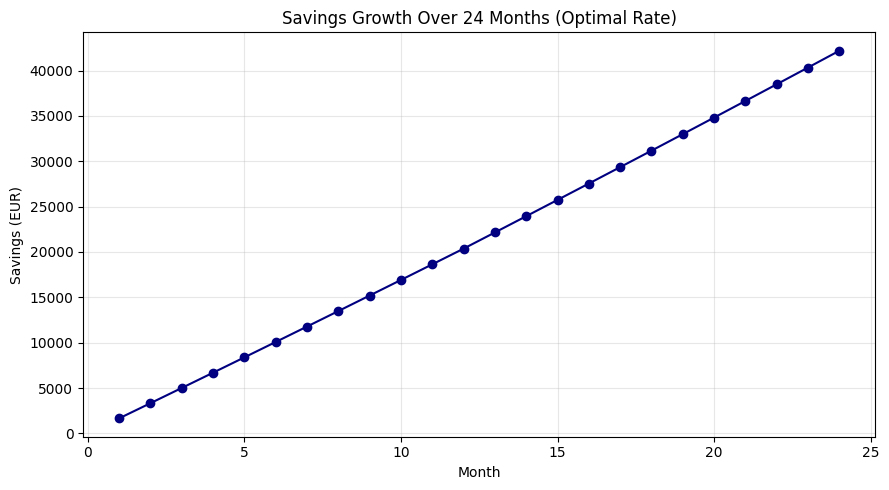

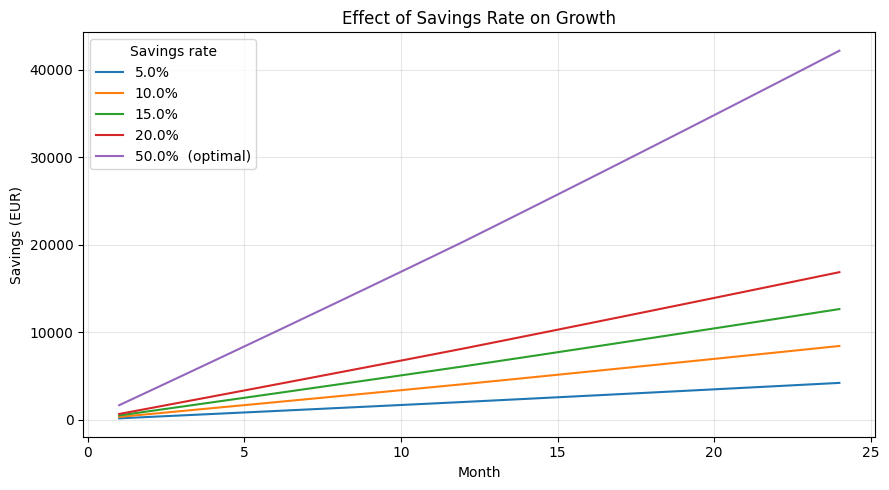

In [ ]:
optimal_history = simulate_savings(40000, optimal_rate, 0.03, 24)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 25), optimal_history, marker="o", color="navy")
plt.title("Savings Growth Over 24 Months (Optimal Rate)")
plt.xlabel("Month")
plt.ylabel("Savings (EUR)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# compare a few different savings rates side by side
plt.figure(figsize=(9, 5))
for rate in [0.05, 0.10, 0.15, 0.20, optimal_rate]:
    history = simulate_savings(40000, rate, 0.03, 24)
    label = f"{rate*100:.1f}%" + ("  (optimal)" if rate == optimal_rate else "")
    plt.plot(range(1, 25), history, label=label)

plt.title("Effect of Savings Rate on Growth")
plt.xlabel("Month")
plt.ylabel("Savings (EUR)")
plt.legend(title="Savings rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##1e - Code Quality, Validity and Assumption

1. Input validation is handled inline (eg portion_saved must be in [0, 1], salary_growth_rate must be in [0.02, 0.08]) and raises ValueError with a clear message rather than failing silently.
2. Functions are kept single-purpose (simulate_savings, time_to_target, final_balance, optimise_savings_rate) so each one is easy to test and reuse.
3. Assumption: interest and the monthly salary contribution are both applied within the same month (interest first, the deposit), matching the order given in the brief.
4. Assumption: salary growth is applied at the end of every 12th month, not continuouly.

#Task 2 - Retail Inventory Management System

##2a - Data Structure Design and Justification

In [ ]:
from dataclasses import dataclass, asdict
import pandas as pd
import os

@dataclass
class Product:
  product_id:
  name:
  category:
  unit_price:
  stock_quantity:


##2b - Inventory Management Operations

In [ ]:
from dataclasses import dataclass, asdict
import pandas as pd
import os

@dataclass
class Product:
  product_id: str
  name: str
  category: str
  unit_price: float
  stock_quantity: int

class InventoryManager:
  def __init__(self):
    self.products = {}

  def add_product(self, product_id, name, category, unit_price, stock_quantity):
    if not product_id or not name or not category:
      raise ValueError("Product ID, Name and Category cannot be empty")
    if unit_price < 0:
      raise ValueError("Unit price cannot be negative")
    if stock_quantity < 0:
      raise ValueError("Stock quantity cannot be negative")
    if product_id in self.products:
      raise ValueError(f"Product '{product_id}' already exist")
    self.products[product_id] = Product(product_id, name, category, float(unit_price), int(stock_quantity))
    return self.products[product_id]

  def update_product(self, product_id, **fields):
    if product_id not in self.products:
      raise KeyError(f"Product '{product_id}' not found")

    product = self.products[product_id]
    for field, value in fields.items():
      if not hasattr(product, field):
        raise ValueError(f"Unknown field '{field}'")
      if field in ("unit_price", "stock_quantity") and value < 0:
        raise ValueError(f"{field} cannot be negative")
      setattr(product, field, value)
    return product

  def delete_product(self, product_id):
    if product_id not in self.products:
      raise KeyError(f"Product '{product_id}' not found")
    del self.products[product_id]

  def get_product(self, product_id):
    if product_id not in self.products:
      raise KeyError(f"Product '{product_id}' not found")
    return self.products[product_id]

  def list_products(self):
    return list(self.products.values())

  def to_dataframe(self):
    return pd.DataFrame([asdict(p) for p in self.products.values()])

  def save_to_csv(self, filepath="inventory.csv"):
    self.to_dataframe().to_csv(filepath, index=False)
    return filepath

  def load_from_csv(self, filepath="inventory.csv"):
    df = pd.read_csv(filepath)
    self.products = {}
    for _, row in df.iterrows():
      # Assuming Product constructor matches the order of columns after fixing Product class
      self.products[row["product_id"]] = Product(row["product_id"], row["name"], row["category"], float(row["unit_price"]), int(row["stock_quantity"]))

inventory = InventoryManager()

sample_products = [
    ("P001", "Wireless Mouse",      "Electronics", 19.99, 120),
    ("P002", "USB-C Cable",          "Electronics", 7.50,  8),
    ("P003", "Office Chair",         "Furniture",   89.00, 15),
    ("P004", "Standing Desk",        "Furniture",   199.99, 4),
    ("P005", "Notebook A5",          "Stationery",  2.30,  300),
    ("P006", "Ballpoint Pen 10-pack","Stationery",  1.80,  5),
    ("P007", "Monitor 24inch",       "Electronics", 129.00, 12),
    ("P008", "Desk Lamp",            "Furniture",   24.50, 3),
]

for pid, name, cat, price, qty in sample_products:
    inventory.add_product(pid, name, cat, price, qty)

inventory.update_product("P002", stock_quantity=50)   # restock
try:
    inventory.add_product("P001", "Duplicate Mouse", "Electronics", 9.99, 10)
except ValueError as e:
    print(f"Duplicate prevented as expected: {e}")

Duplicate prevented as expected: Product 'P001' already exist


##2c - Data Processing and Analysis using pandas

In [ ]:
csv_path = inventory.save_to_csv("inventory.csv")
df = pd.read_csv(csv_path)
df.head()

,product_id,name,category,unit_price,stock_quantity
0,P001,Wireless Mouse,Electronics,19.99,120
1,P002,USB-C Cable,Electronics,7.50,50
2,P003,Office Chair,Furniture,89.00,15
3,P004,Standing Desk,Furniture,199.99,4
4,P005,Notebook A5,Stationery,2.30,300


In [ ]:
category_summary = df.groupby("category").agg(
    total_products=("product_id", "count"),
    total_stock=("stock_quantity", "sum"),
    avg_unit_price=("unit_price", "mean"),
    inventory_value=("unit_price", lambda x: (x * df.loc[x.index, "stock_quantity"]).sum())
).round(2)

print("Category-wise summary:")
category_summary

Category-wise summary:


,total_products,total_stock,avg_unit_price,inventory_value
category,,,,
Electronics,3,182,52.16,4321.80
Furniture,3,22,104.50,2208.46
Stationery,2,305,2.05,699.00


In [ ]:
LOW_STOCK_THRESHOLD = 10

low_stock_items = df[df["stock_quantity"] < LOW_STOCK_THRESHOLD].sort_values("stock_quantity")
print(f"{len(low_stock_items)} product(s) below the low-stock threshold of {LOW_STOCK_THRESHOLD}:")
low_stock_items

3 product(s) below the low-stock threshold of 10:


,product_id,name,category,unit_price,stock_quantity
7,P008,Desk Lamp,Furniture,24.50,3
3,P004,Standing Desk,Furniture,199.99,4
5,P006,Ballpoint Pen 10-pack,Stationery,1.80,5


In [ ]:
df["inventory_value"] = df["unit_price"] * df["stock_quantity"]

print(f"Total products: {len(df)}")
print(f"Total units in stock: {df['stock_quantity'].sum()}")
print(f"Total inventory value: EUR {df['inventory_value'].sum():,.2f}")
print(f"Most valuable category: {category_summary['inventory_value'].idxmax()}")
print(f"Products needing reorder: {len(low_stock_items)}")


Total products: 8
Total units in stock: 509
Total inventory value: EUR 7,229.26
Most valuable category: Electronics
Products needing reorder: 3


##2d - Data Visualization

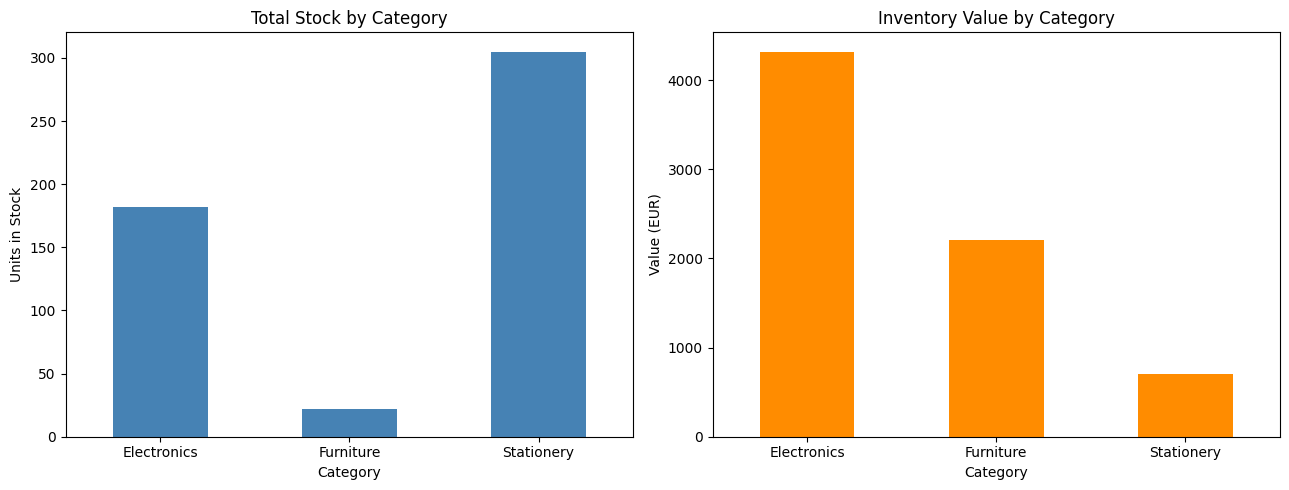

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# total stock per category
category_summary["total_stock"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Stock by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Units in Stock")
axes[0].tick_params(axis="x", rotation=0)

# inventory value per category
category_summary["inventory_value"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Inventory Value by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Value (EUR)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


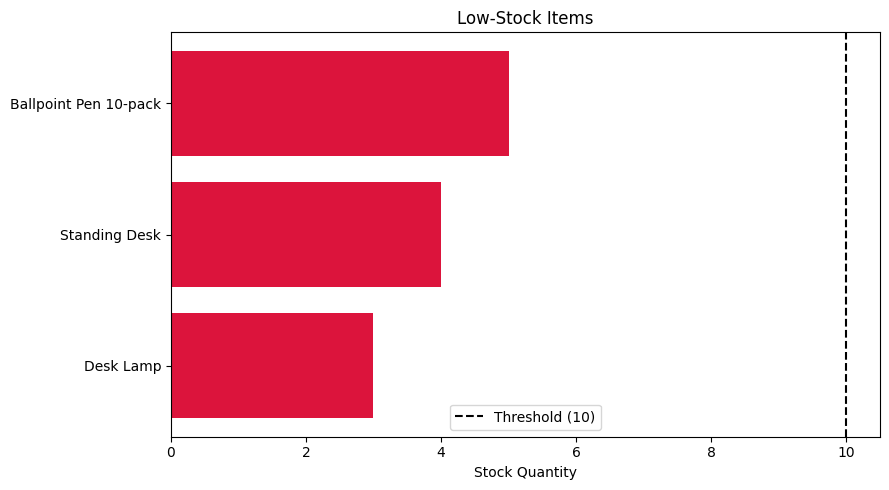

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(low_stock_items["name"], low_stock_items["stock_quantity"], color="crimson")
plt.axvline(LOW_STOCK_THRESHOLD, color="black", linestyle="--", label=f"Threshold ({LOW_STOCK_THRESHOLD})")
plt.title("Low-Stock Items")
plt.xlabel("Stock Quantity")
plt.legend()
plt.tight_layout()
plt.show()

##2e - Code Quality, Structure and Robustnes
1. Product and InventoryManager separate data from behaviour, easy to extend later (eg add a supplier field) without touching the manager logic.
2. Every public method validates its unputs and raises a specific exception (ValueError, KeyError) with a readable message, rather than failing silently or crashing with a generic error.
3. CSV persistence (save_to_csv/load_from_csv) decouple the analysis step from the in-memory object, matching the brief's requirement that visualisations come from the processed CSV.

#Task 3 - DBS Timetabling and Enrolment System

##Part 1

In [ ]:
class SchedulingConflictError(Exception):
    "Raised when a day/time slot is already taken."
    pass


class Venue:
    def __init__(self, capacity, room_number):
        if capacity <= 0:
            raise ValueError("capacity must be positive")
        self.capacity = capacity
        self.room_number = room_number
        self.timetable = {}  # (day, startTime) -> Module

    def addModule(self, module):
        """Assign a module to this venue's timetable. Raises if there's a clash."""
        slot = (module.day, module.startTime)
        if slot[0] is None or slot[1] is None:
            raise ValueError("Module must have a day and startTime set before "
                              "it can be added to a venue")
        if slot in self.timetable:
            raise SchedulingConflictError(
                f"Room {self.room_number} is already booked on "
                f"{slot[0]} at {slot[1]}")

        self.timetable[slot] = module
        module.location = self.room_number
        return True


##Part 2

In [ ]:
class Module:
    def __init__(self, subject, location, hours, day=None, startTime=None, lecturer=None):
        if hours <= 0:
            raise ValueError("hours must be positive")
        self.subject = subject
        self.location = location
        self.hours = hours
        self.day = day
        self.startTime = startTime
        self.lecturer = lecturer
        self.enrolled_students = []
        self.capacity = None  # can be linked to a Venue's capacity later

    def setLecturer(self, lecturer):
        """Assign a lecturer if they teach this subject and are free at this time."""
        if self.subject not in lecturer.subjects:
            print(f"Assignment failed: {lecturer.name} does not teach {self.subject}")
            return False

        if self.day is not None and self.startTime is not None:
            if not lecturer.is_available(self.day, self.startTime):
                print(f"Assignment failed: {lecturer.name} is not available "
                      f"on {self.day} at {self.startTime}")
                return False

        self.lecturer = lecturer
        lecturer.timetable.append((self.day, self.startTime, self.subject))
        print(f"{lecturer.name} assigned to {self.subject}")
        return True

    def setTimetable(self, day, startTime):
        """Set/move this module's day & time, checking the lecturer is free."""
        if self.lecturer is not None:
            if not self.lecturer.is_available(day, startTime):
                print(f"Timetabling failed: {self.lecturer.name} is not free "
                      f"on {day} at {startTime}")
                return False
            # update the lecturer's record of this slot
            self.lecturer.timetable = [
                slot for slot in self.lecturer.timetable
                if slot[2] != self.subject
            ]
            self.lecturer.timetable.append((day, startTime, self.subject))

        self.day = day
        self.startTime = startTime
        print(f"{self.subject} timetabled for {day} at {startTime}")
        return True

##Part 3

In [ ]:
class Lecturer:
    def __init__(self, name, location):
        self.name = name
        self.location = location
        self.subjects = set()
        self.timetable = []  # list of (day, startTime, subject)

    def addSubject(self, subject):
        self.subjects.add(subject)

    def is_available(self, day, startTime):
        "A lecturer is unavailable if they already have a class at that exact slot."
        return not any(slot[0] == day and slot[1] == startTime for slot in self.timetable)

##Part 4

In [ ]:
class Student:
    def __init__(self, name, course):
        self.name = name
        self.course = course
        self.modules = []  # list of Module objects

    def addModule(self, module):
        # capacity check
        if module.capacity is not None and len(module.enrolled_students) >= module.capacity:
            print(f"Enrolment failed: {module.subject} is at full capacity")
            return False

        # timetable clash check against modules already taken
        for existing in self.modules:
            if existing.day == module.day and existing.startTime == module.startTime:
                print(f"Enrolment failed: {module.subject} clashes with "
                      f"{existing.subject} ({module.day} {module.startTime})")
                return False

        self.modules.append(module)
        module.enrolled_students.append(self)
        print(f"{self.name} enrolled in {module.subject}")
        return True

##Putting it together: input validation, exception, and a worked example

In [ ]:
room_a = Venue(capacity=30, room_number="A101")
room_b = Venue(capacity=25, room_number="B202")

dr_smith = Lecturer("Dr. Smith", "Block A")
dr_smith.addSubject("Programming for Data Analysis")
dr_smith.addSubject("Statistics")

prog_module = Module(subject="Programming for Data Analysis", location=None, hours=3)
prog_module.setTimetable("Monday", "10:00")
prog_module.setLecturer(dr_smith)        # should succeed - subject matches, lecturer free
prog_module.capacity = 2                  # small capacity to demo the capacity check below
room_a.addModule(prog_module)

stats_module = Module(subject="Statistics", location=None, hours=2)
stats_module.setTimetable("Monday", "10:00")   # same slot as Dr Smith's other class
stats_module.setLecturer(dr_smith)              # should FAIL - lecturer already booked then

print()

# venue conflict demo
other_module = Module(subject="Statistics", location=None, hours=2, day="Monday", startTime="10:00")
try:
    room_a.addModule(other_module)   # same room, same slot as prog_module -> should raise
except SchedulingConflictError as e:
    print(f"Caught expected error: {e}")

print()

# student enrolment + capacity demo
student1 = Student("Osamuyi", "MSc Data Analytics")
student2 = Student("Jude", "MSc Data Analytics")
student3 = Student("Uwaila", "MSc Data Analytics")

student1.addModule(prog_module)   # ok
student2.addModule(prog_module)   # ok - hits capacity of 2
student3.addModule(prog_module)   # should fail - module full

# clash demo: student1 tries to join another module at the same time
clashing_module = Module(subject="Statistics", location=None, hours=2,
                          day="Monday", startTime="10:00")
student1.addModule(clashing_module)   # should fail - timetable clash


Programming for Data Analysis timetabled for Monday at 10:00
Dr. Smith assigned to Programming for Data Analysis
Statistics timetabled for Monday at 10:00
Assignment failed: Dr. Smith is not available on Monday at 10:00

Caught expected error: Room A101 is already booked on Monday at 10:00

Osamuyi enrolled in Programming for Data Analysis
Jude enrolled in Programming for Data Analysis
Enrolment failed: Programming for Data Analysis is at full capacity
Enrolment failed: Statistics clashes with Programming for Data Analysis (Monday 10:00)


False

#Wrapping up
Each task above runs top to bottom in Colab independently, but Task 1, 2 and 3 don't depend on each other so you can run/test them separately while you're getting familiar with the logic.

A few things worth understanding before you submit, since they're the kind of thing that comes up in viva/feedback:

1. Task 1c: why bisection search works here (the relationship between savings rate and final balance in monotonic).
2. Task 2a: the O(1) vs O(n) argument for dict vs list lookup.
3. Task 3: how the conflict checks cascade - a venue checks itself, a lecturer checks themself, and a student checks themself, each independently, when addModule is called.